GigSmart AI — Exploratory Data Analysis (EDA)

This notebook explores the processed dataset to identify patterns and prepare data for machine learning.

## What We Will Analyze
- Order timing patterns  
- Weather conditions  
- Festival impact   
- Zone type distribution  
- Distance and delivery time  
- Expected payout  
- Fuel and time cost  
- Net profit trends  
- Best app distribution

## Target Prediction

We aim to predict the most profitable platform:

- Zomato  
- Swiggy  
- Blinkit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style set karo
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Dataset load karo
df = pd.read_csv('../data/processed/gigsmart_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset loaded successfully!
Shape: (45593, 16)

Columns: ['hour', 'day_of_week', 'is_weekend', 'is_festival', 'weather', 'zone_type', 'is_lunch_time', 'is_dinner_time', 'distance_km', 'estimated_time_min', 'app_name', 'expected_payout', 'fuel_cost', 'time_cost', 'net_profit', 'best_app']


,hour,day_of_week,is_weekend,is_festival,weather,zone_type,is_lunch_time,is_dinner_time,distance_km,estimated_time_min,app_name,expected_payout,fuel_cost,time_cost,net_profit,best_app
0,11,5,1,0,clear,normal,0,0,4.2,24,Swiggy,101.55,21.0,36.0,44.55,Swiggy
1,19,4,0,0,rain,low,0,1,14.5,33,Blinkit,220.01,72.5,49.5,98.01,Swiggy
2,8,5,1,0,fog,normal,0,0,6.4,26,Blinkit,104.92,32.0,39.0,33.92,Swiggy
3,18,1,0,0,clear,normal,0,0,5.6,21,Swiggy,103.39,28.0,31.5,43.89,Zomato
4,13,5,1,0,clear,busy,1,0,1.0,30,Zomato,75.56,5.0,45.0,25.56,Zomato



Basic statistics to understand the distribution 
of numerical features.

In [2]:
print("Total Records:", len(df))
print("Total Features:", len(df.columns))
print("\nNumerical Stats:")
print(df.describe().round(2))

Total Records: 45593
Total Features: 16

Numerical Stats:
           hour  day_of_week  is_weekend  is_festival  is_lunch_time  \
count  45593.00     45593.00    45593.00     45593.00       45593.00   
mean      17.56         3.00        0.28         0.02           0.05   
std        4.77         1.97        0.45         0.14           0.23   
min        0.00         0.00        0.00         0.00           0.00   
25%       15.00         1.00        0.00         0.00           0.00   
50%       19.00         3.00        0.00         0.00           0.00   
75%       21.00         5.00        1.00         0.00           0.00   
max       23.00         6.00        1.00         1.00           1.00   

       is_dinner_time  distance_km  estimated_time_min  expected_payout  \
count        45593.00     45593.00            45593.00         45593.00   
mean             0.44         5.65               26.29           111.22   
std              0.50         4.47                9.38            42

hour mean     = 17.56  → Evening orders dominant  
distance mean = 5.65km → Realistic India delivery  
time mean     = 26 min → Normal delivery time  
payout mean   = ₹111   → Good earning per order  
net_profit 50%= ₹41.48 → Most orders profitable  

#Best App Distribution  
Which app is most profitable across different conditions?

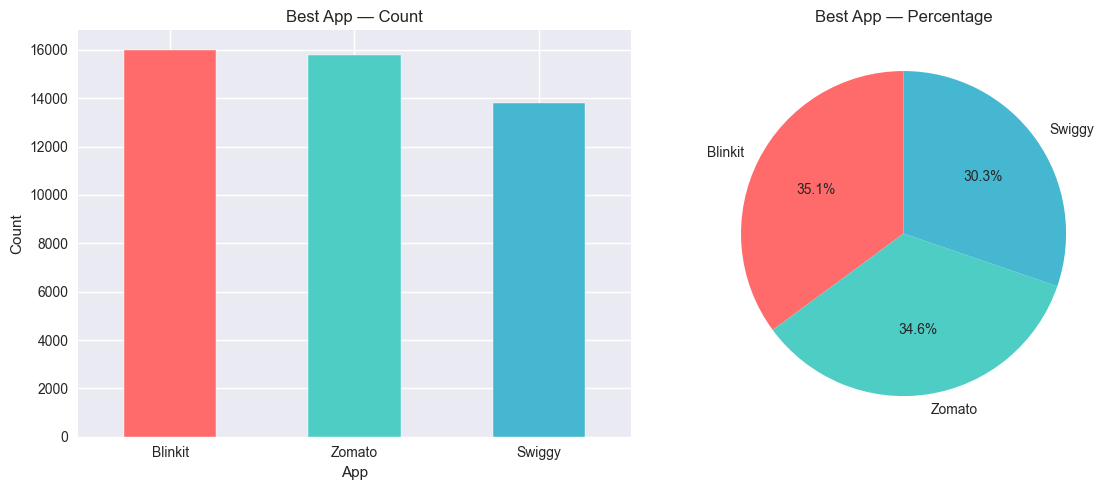

Distribution:
best_app
Blinkit    16007
Zomato     15794
Swiggy     13792
Name: count, dtype: int64


In [3]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
df['best_app'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    edgecolor='white'
)
axes[0].set_title('Best App — Count')
axes[0].set_xlabel('App')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['best_app'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Best App — Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Distribution:")
print(df['best_app'].value_counts())

### Observation
The dataset shows a fairly balanced distribution   
across all three platforms:  
Blinkit: 35.1% — strongest in busy metro zones  
Zomato: 34.6% — strongest during lunch and festivals    
Swiggy: 30.3% — strongest on weekends and rainy days  

### Insight  
No single app dominates overall. Each platform has   
specific conditions where it outperforms others.  
This validates our ML approach — a simple rule-based   
system would not capture these nuanced patterns.  

##Net Profit Analysis  
Understanding earning patterns for gig workers.

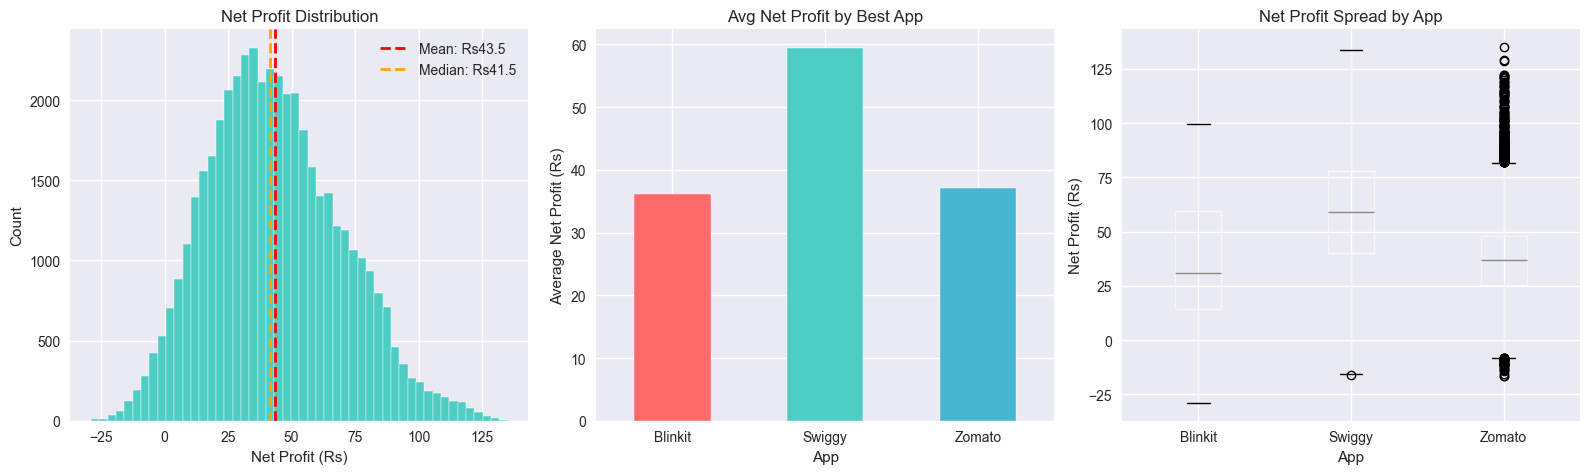

Avg Net Profit by App:
best_app
Blinkit    36.18
Swiggy     59.42
Zomato     37.13
Name: net_profit, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 - Distribution
axes[0].hist(df['net_profit'], bins=50,
             color='#4ECDC4', edgecolor='white')
axes[0].axvline(df['net_profit'].mean(),
                color='red', linestyle='--',
                linewidth=2,
                label=f"Mean: Rs{df['net_profit'].mean():.1f}")
axes[0].axvline(df['net_profit'].median(),
                color='orange', linestyle='--',
                linewidth=2,
                label=f"Median: Rs{df['net_profit'].median():.1f}")
axes[0].set_title('Net Profit Distribution')
axes[0].set_xlabel('Net Profit (Rs)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2 - Avg profit by app
df.groupby('best_app')['net_profit'].mean().plot(
    kind='bar',
    ax=axes[1],
    color=colors,
    edgecolor='white'
)
axes[1].set_title('Avg Net Profit by Best App')
axes[1].set_xlabel('App')
axes[1].set_ylabel('Average Net Profit (Rs)')
axes[1].tick_params(axis='x', rotation=0)

# Plot 3 - Boxplot
df.boxplot(column='net_profit', by='best_app',
           ax=axes[2])
axes[2].set_title('Net Profit Spread by App')
axes[2].set_xlabel('App')
axes[2].set_ylabel('Net Profit (Rs)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Avg Net Profit by App:")
print(df.groupby('best_app')['net_profit'].mean().round(2))

#Net Profit Analysis

Observations  
- Average net profit per order: Rs 43.5
- Most orders fall in Rs 25-60 range  
- Swiggy orders show highest average profit (Rs 59.42)  
  due to rain surge and weekend bonuses  
- Negative profits exist for long-distance,  
  low-payout orders — realistic scenario  

Insights  
Swiggy generates highest profit per order when it   
is the best app, primarily because Swiggy becomes   
best during high-surge conditions like rain and weekends.  
This justifies why smart platform switching matters.  

#Time-Based Patterns  
How order demand and profitability vary throughout the day.

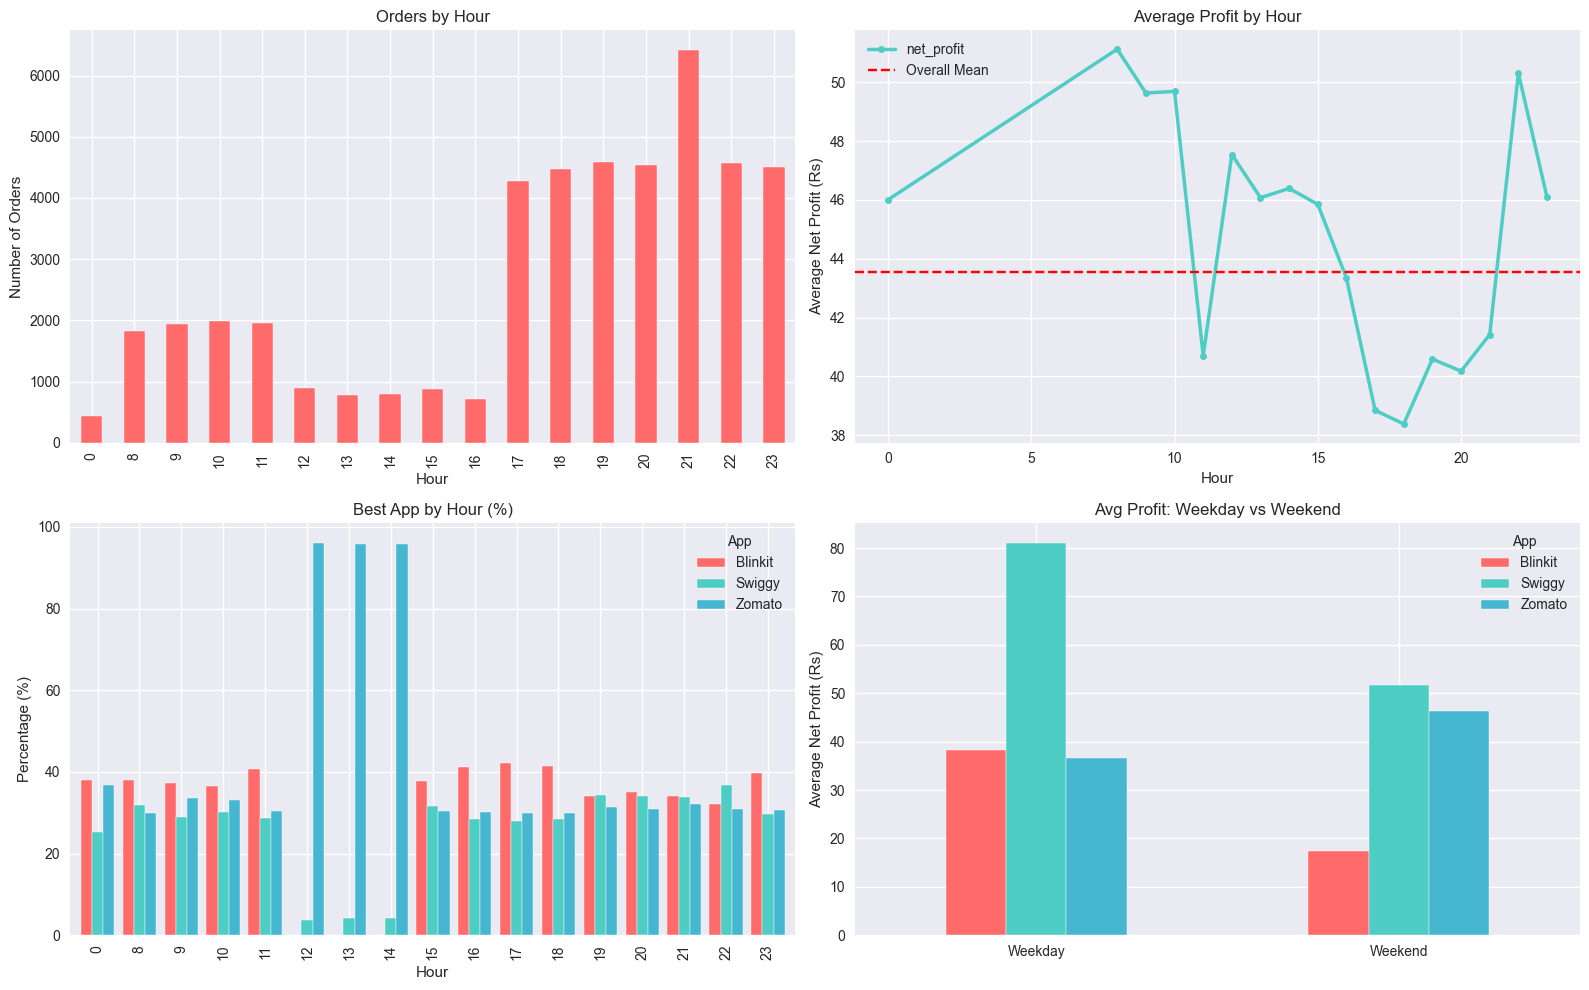

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1 - Orders by hour
df['hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0],
    color='#FF6B6B', edgecolor='white'
)
axes[0,0].set_title('Orders by Hour')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Number of Orders')

# Plot 2 - Avg profit by hour
df.groupby('hour')['net_profit'].mean().plot(
    kind='line', ax=axes[0,1],
    color='#4ECDC4', linewidth=2.5,
    marker='o', markersize=5
)
axes[0,1].set_title('Average Profit by Hour')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Average Net Profit (Rs)')
axes[0,1].axhline(df['net_profit'].mean(),
                   color='red', linestyle='--',
                   label='Overall Mean')
axes[0,1].legend()

# Plot 3 - Best app by hour
hour_app = pd.crosstab(
    df['hour'], df['best_app'],
    normalize='index'
) * 100
hour_app.plot(kind='bar', ax=axes[1,0],
              color=colors, edgecolor='white',
              width=0.8)
axes[1,0].set_title('Best App by Hour (%)')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend(title='App')

# Plot 4 - Weekend vs Weekday
weekend_profit = df.groupby(
    ['is_weekend', 'best_app']
)['net_profit'].mean().unstack()
weekend_profit.index = ['Weekday', 'Weekend']
weekend_profit.plot(kind='bar', ax=axes[1,1],
                    color=colors, edgecolor='white')
axes[1,1].set_title('Avg Profit: Weekday vs Weekend')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Average Net Profit (Rs)')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='App')

plt.tight_layout()
plt.show()

Graph 1: Evening (5-11 PM) pe sabse zyada orders  
Graph 2: Subah + Lunch pe per order profit zyada  
Graph 3: Har time pe alag app best hoti hai  
Graph 4: Weekend pe Swiggy clearly sabse best  

#Weather Impact Analysis  
How weather conditions affect delivery earnings   
and app preference.  

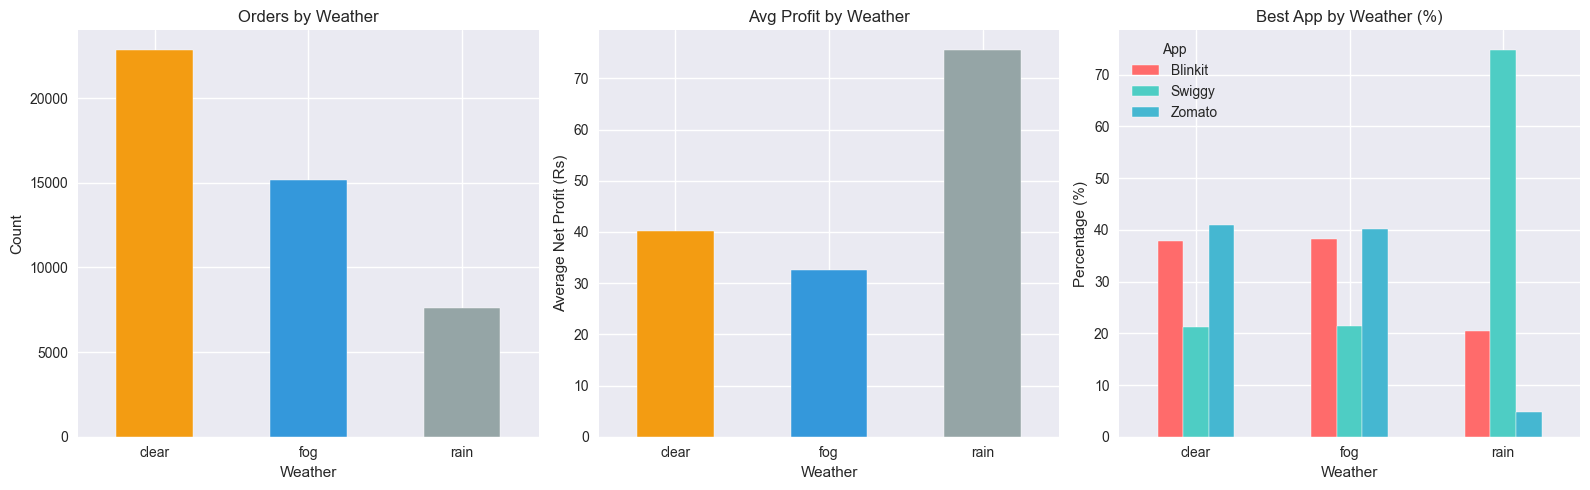

Avg Profit by Weather:
weather
clear    40.14
fog      32.62
rain     75.59
Name: net_profit, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 - Orders by weather
df['weather'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#F39C12', '#3498DB', '#95A5A6'],
    edgecolor='white'
)
axes[0].set_title('Orders by Weather')
axes[0].set_xlabel('Weather')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 - Avg profit by weather
df.groupby('weather')['net_profit'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#F39C12', '#3498DB', '#95A5A6'],
    edgecolor='white'
)
axes[1].set_title('Avg Profit by Weather')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Average Net Profit (Rs)')
axes[1].tick_params(axis='x', rotation=0)

# Plot 3 - Best app by weather
weather_app = pd.crosstab(
    df['weather'], df['best_app'],
    normalize='index'
) * 100
weather_app.plot(kind='bar', ax=axes[2],
                 color=colors, edgecolor='white')
axes[2].set_title('Best App by Weather (%)')
axes[2].set_xlabel('Weather')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='App')

plt.tight_layout()
plt.show()

print("Avg Profit by Weather:")
print(df.groupby('weather')['net_profit'].mean().round(2))

Key Findings  
- Rain generates highest profit (Rs 75.59) —   
  almost 2x clear weather (Rs 40.14)  
- Fog reduces earnings (Rs 32.62) due to   
  slower delivery and higher time cost  
- During rain, Zomato dominates (70%) due to   
  aggressive surge pricing and driver incentives  
- Clear weather shows balanced distribution   
  across all three apps  

Insight  
Weather is the strongest single factor affecting   
earnings. A driver who switches to Zomato during   
rain can nearly double their per-order profit.  